# Rachel Clusters — Model Results Analysis

Configurable notebook — set the experiment paths below to analyze any run.

**Run on a pod with the network volume.**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

ROOT = Path("/workspace/farm-mapping")
PARQUET_PATH = ROOT / "data" / "rachel_geometry_candidates" / "selected_clusters_relabeled.parquet"
PATCHES_DIR = ROOT / "data" / "patches"
SPLITS_DIR = PATCHES_DIR / "splits"

# ============================================================
# CHANGE THESE TO SWITCH BETWEEN EXPERIMENTS
# ============================================================
EXPERIMENT = "rachel_clusters_v2"          # or "rachel_poultry_v1"
OUTPUT = ROOT / "data" / "output" / EXPERIMENT
CANDIDATES_DIR = ROOT / "data" / "rachel_geometry_candidates" / "candidates"  # or "candidates_poultry"
SPLITS_FILE = SPLITS_DIR / f"{EXPERIMENT}.csv"
CNN_THRESHOLD = 0.7        # model classification threshold
IF_THRESHOLD = 0.067       # Rachel's isolation forest threshold (85% of DMV poultry farms >= this)
# ============================================================

COLORS = {"TP": "#2ecc71", "FP": "#e74c3c", "FN": "#f39c12", "TN": "#3498db"}

# Load scored candidates
scored = pd.read_parquet(OUTPUT / "scored_candidates.parquet")
print(f"Experiment: {EXPERIMENT}")
print(f"Scored candidates: {len(scored)}")
print(f"CNN threshold: {CNN_THRESHOLD}")
print(f"IF threshold: {IF_THRESHOLD}")

# Derive pred_class using configured threshold
scored["pred_class"] = "TN"
scored.loc[(scored["predicted_score"] >= CNN_THRESHOLD) & (scored["true_label"] == 1), "pred_class"] = "TP"
scored.loc[(scored["predicted_score"] >= CNN_THRESHOLD) & (scored["true_label"] == 0), "pred_class"] = "FP"
scored.loc[(scored["predicted_score"] < CNN_THRESHOLD) & (scored["true_label"] == 1), "pred_class"] = "FN"

# Load rachel parquet for extra columns
rachel = pd.read_parquet(PARQUET_PATH)
label_map = dict(zip(rachel["cluster_id"].astype(str), rachel["modified_label"]))
score_if_map = dict(zip(rachel["cluster_id"].astype(str), rachel["template_score_if"]))
scored["farm_type"] = scored["candidate_id"].astype(str).map(label_map)
scored["template_score_if"] = scored["candidate_id"].astype(str).map(score_if_map)

# Load country from candidates
cands = pd.concat([pd.read_csv(f) for f in sorted(CANDIDATES_DIR.glob("*.csv"))], ignore_index=True)
country_map = dict(zip(cands["id"].astype(str), cands["country"]))
scored["country"] = scored["candidate_id"].astype(str).map(country_map)

# Load splits
if SPLITS_FILE.exists():
    splits = pd.read_csv(SPLITS_FILE)
    split_map = dict(zip(splits["candidate_id"].astype(str), splits["split"]))
    scored["split"] = scored["candidate_id"].astype(str).map(split_map)
    print(f"Splits: {scored['split'].value_counts().to_dict()}")
else:
    print(f"No splits file at {SPLITS_FILE}")

print(f"
Prediction distribution: {scored['pred_class'].value_counts().to_dict()}")

Experiment: rachel_clusters_v2
Scored candidates: 15130
No splits file at /home/filip/code/farm-mapping/data/patches/splits/rachel_clusters_v2.csv

Prediction distribution: {'TP': 11460, 'TN': 2839, 'FP': 680, 'FN': 151}


## 1. Overall Metrics

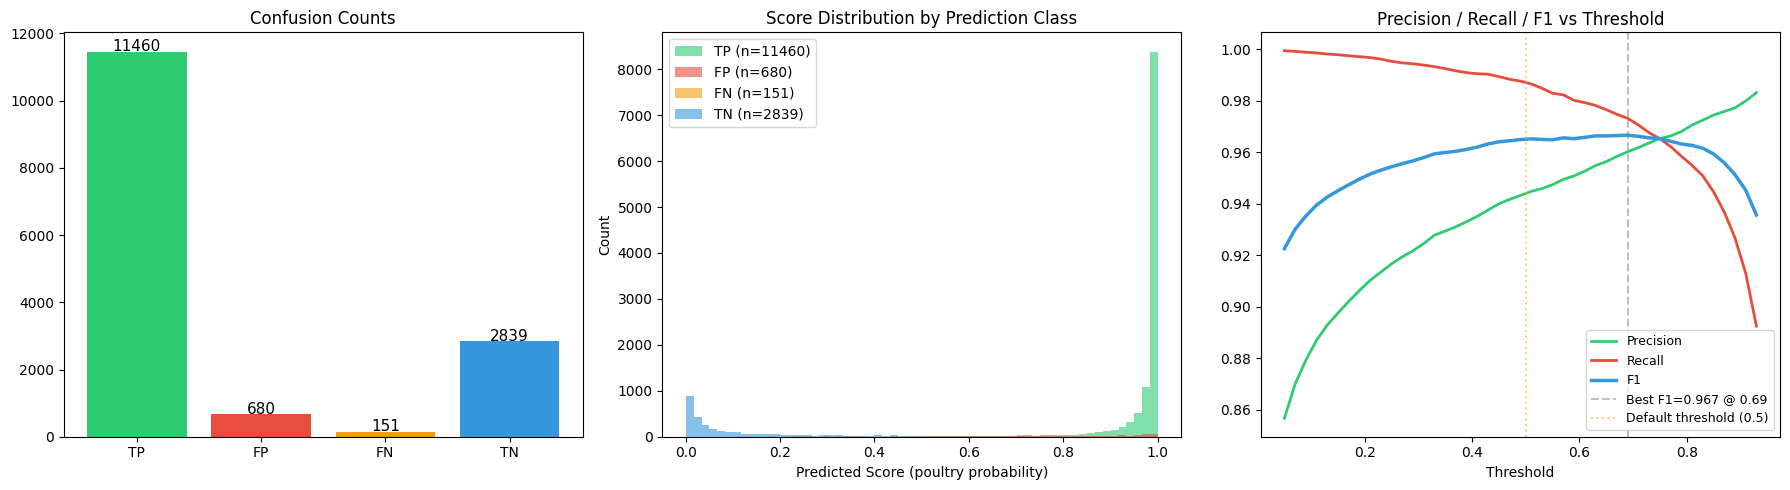

Overall:  Prec=0.944  Rec=0.987  F1=0.965  Acc=0.945
          TP=11460  FP=680  FN=151  TN=2839


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion counts
pred_classes = scored["pred_class"].value_counts()
counts = [pred_classes.get(k, 0) for k in ["TP", "FP", "FN", "TN"]]
axes[0].bar(["TP", "FP", "FN", "TN"], counts, color=[COLORS[k] for k in ["TP", "FP", "FN", "TN"]])
axes[0].set_title("Confusion Counts")
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=11)

# Score distributions by pred_class
for cls in ["TP", "FP", "FN", "TN"]:
    subset = scored[scored["pred_class"] == cls]
    if len(subset) > 0:
        axes[1].hist(subset["predicted_score"], bins=30, alpha=0.6, label=f"{cls} (n={len(subset)})", color=COLORS[cls])
axes[1].set_xlabel("Predicted Score (positive class probability)")
axes[1].set_ylabel("Count")
axes[1].set_title("Score Distribution by Prediction Class")
axes[1].legend()

# Precision-Recall by threshold
thresholds = np.arange(0.05, 0.95, 0.02)
precs, recs, f1s = [], [], []
for t in thresholds:
    pred = (scored["predicted_score"] >= t).astype(int)
    true = scored["true_label"].astype(int)
    tp = ((pred == 1) & (true == 1)).sum()
    fp = ((pred == 1) & (true == 0)).sum()
    fn = ((pred == 0) & (true == 1)).sum()
    p = tp / max(tp + fp, 1)
    r = tp / max(tp + fn, 1)
    f = 2 * p * r / max(p + r, 1e-8)
    precs.append(p); recs.append(r); f1s.append(f)
axes[2].plot(thresholds, precs, label="Precision", color="#2ecc71", lw=2)
axes[2].plot(thresholds, recs, label="Recall", color="#e74c3c", lw=2)
axes[2].plot(thresholds, f1s, label="F1", color="#3498db", linewidth=2.5)
best_idx = np.argmax(f1s)
axes[2].axvline(thresholds[best_idx], color="gray", linestyle="--", alpha=0.5, label=f"Best F1={f1s[best_idx]:.3f} @ {thresholds[best_idx]:.2f}")
axes[2].axvline(0.5, color="orange", linestyle=":", alpha=0.5, label="Default threshold (0.5)")
axes[2].set_xlabel("Threshold")
axes[2].set_title("Precision / Recall / F1 vs Threshold")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print metrics
tp, fp, fn, tn = counts
prec = tp / max(tp + fp, 1)
rec = tp / max(tp + fn, 1)
f1 = 2 * prec * rec / max(prec + rec, 1e-8)
print(f"Overall:  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  Acc={(tp+tn)/sum(counts):.3f}")
print(f"          TP={tp}  FP={fp}  FN={fn}  TN={tn}")

## 2. Per-Split Metrics (Train / Val / Test / Inspected)

In [7]:
split_rows = []
for split_name in ("train", "val", "test", "inspected"):
    grp = scored[scored["split"] == split_name]
    if len(grp) == 0:
        continue
    tp = (grp["pred_class"] == "TP").sum()
    fp = (grp["pred_class"] == "FP").sum()
    fn = (grp["pred_class"] == "FN").sum()
    tn = (grp["pred_class"] == "TN").sum()
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-8)
    split_rows.append({"Split": split_name, "N": len(grp), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                       "Precision": f"{prec:.3f}", "Recall": f"{rec:.3f}", "F1": f"{f1:.3f}"})

display(pd.DataFrame(split_rows))

,Split,N,TP,FP,FN,TN,Precision,Recall,F1
0,train,9819,7477,346,90,1906,0.956,0.988,0.972
1,val,2103,1592,76,29,406,0.954,0.982,0.968
2,test,2103,1603,73,18,409,0.956,0.989,0.972
3,inspected,1105,788,185,14,118,0.810,0.983,0.888


## 3. CNN Probability by Prediction Class & Country

In [8]:
# Table: TP/FP/FN/TN with median scores per country
print(f"{'':20s}  {'TP':>4s} {'(med)':>6s}   {'FP':>4s} {'(med)':>6s}   {'FN':>4s} {'(med)':>6s}   {'TN':>4s} {'(med)':>6s}")
print("-" * 80)
for country in sorted(scored["country"].dropna().unique()):
    sub = scored[scored["country"] == country]
    parts = [f"{country:20s}"]
    for cls in ("TP", "FP", "FN", "TN"):
        csub = sub[sub["pred_class"] == cls]
        n = len(csub)
        if n > 0:
            parts.append(f"  {n:4d} {csub['predicted_score'].median():6.3f}")
        else:
            parts.append(f"  {n:4d}      -")
    print("".join(parts))

# Total row
parts = [f"{'ALL':20s}"]
for cls in ("TP", "FP", "FN", "TN"):
    csub = scored[scored["pred_class"] == cls]
    n = len(csub)
    parts.append(f"  {n:4d} {csub['predicted_score'].median():6.3f}" if n > 0 else f"  {n:4d}      -")
print("-" * 80)
print("".join(parts))

                        TP  (med)     FP  (med)     FN  (med)     TN  (med)
--------------------------------------------------------------------------------
Brazil                 460  0.988   122  0.870     4  0.375   119  0.153
Chile                  431  0.994    43  0.888     7  0.376    24  0.247
Mexico                2174  0.991   128  0.805    45  0.331   161  0.194
Thailand               513  0.967   119  0.736    61  0.265   250  0.165
United States         7882  0.997   268  0.803    34  0.320  2285  0.027
--------------------------------------------------------------------------------
ALL                   11460  0.996   680  0.809   151  0.323  2839  0.039


## 4. CNN Probability by Farm/Building Type

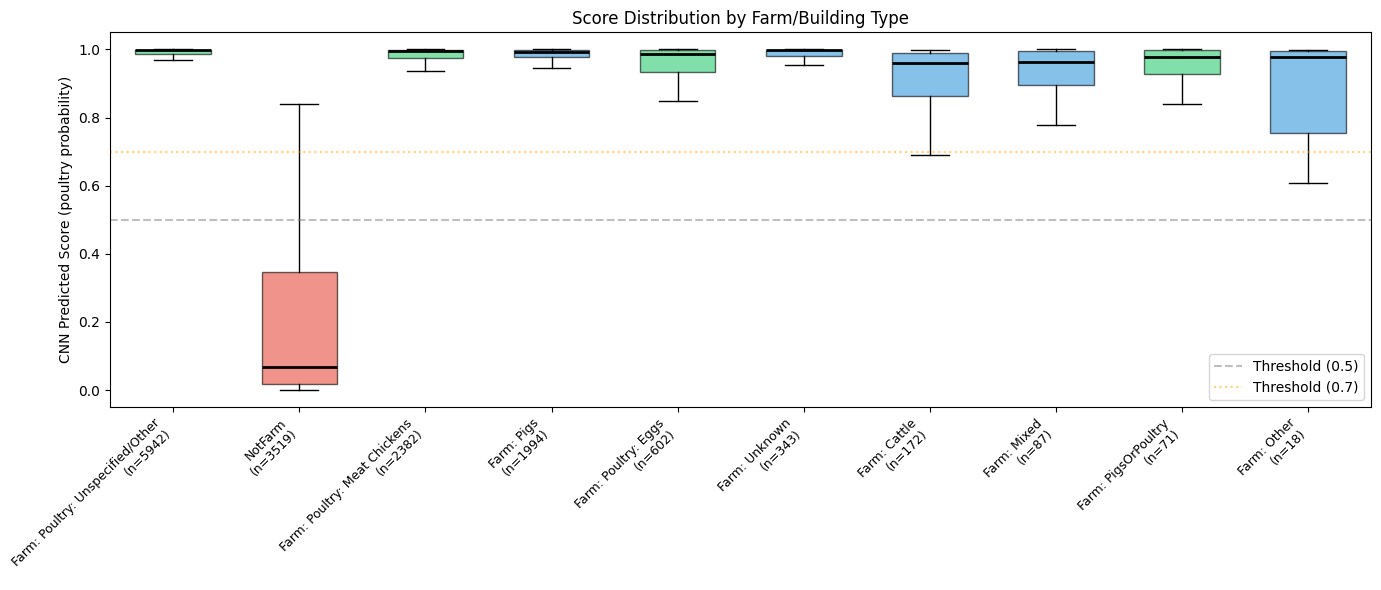

Farm Type                                    N    TP    FP    FN    TN  med score
--------------------------------------------------------------------------------
Farm: Poultry: Unspecified/Other          5942  5908     0    34     0      0.997
NotFarm                                   3519     0   680     0  2839      0.068
Farm: Poultry: Meat Chickens              2382  2343     0    39     0      0.995
Farm: Pigs                                1994  1973     0    21     0      0.993
Farm: Poultry: Eggs                        602   577     0    25     0      0.986
Farm: Unknown                              343   330     0    13     0      0.998
Farm: Cattle                               172   160     0    12     0      0.961
Farm: Mixed                                 87    82     0     5     0      0.962
Farm: PigsOrPoultry                         71    70     0     1     0      0.977
Farm: Other                                 18    17     0     1     0      0.976


In [9]:
# Show score distribution by farm/building type
farm_types = scored["farm_type"].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
positions = []
labels = []
for i, ft in enumerate(farm_types):
    if pd.isna(ft):
        continue
    sub = scored[scored["farm_type"] == ft]
    is_poultry = "Poultry" in ft
    color = "#2ecc71" if is_poultry else "#e74c3c" if ft == "NotFarm" else "#3498db"
    bp = ax.boxplot(sub["predicted_score"].values, positions=[i], widths=0.6,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color="black", linewidth=2))
    labels.append(f"{ft}\n(n={len(sub)})")
    positions.append(i)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Threshold (0.5)")
ax.axhline(0.7, color="orange", linestyle=":", alpha=0.5, label="Threshold (0.7)")
ax.set_ylabel("CNN Predicted Score (positive class probability)")
ax.set_title("Score Distribution by Farm/Building Type")
ax.legend()
plt.tight_layout()
plt.show()

# Table
print(f"{'Farm Type':40s} {'N':>5s} {'TP':>5s} {'FP':>5s} {'FN':>5s} {'TN':>5s} {'med score':>10s}")
print("-" * 80)
for ft in farm_types:
    if pd.isna(ft): continue
    sub = scored[scored["farm_type"] == ft]
    tp = (sub["pred_class"] == "TP").sum()
    fp = (sub["pred_class"] == "FP").sum()
    fn = (sub["pred_class"] == "FN").sum()
    tn = (sub["pred_class"] == "TN").sum()
    print(f"{ft:40s} {len(sub):5d} {tp:5d} {fp:5d} {fn:5d} {tn:5d} {sub['predicted_score'].median():10.3f}")

## 5. CNN Probability by Farm Type & Country

In [10]:
for ft in farm_types:
    if pd.isna(ft): continue
    grp = scored[scored["farm_type"] == ft]
    if len(grp) < 5: continue
    print(f"{ft} (N={len(grp)})")
    print(f"  {'Country':20s} {'N':>4s}  {'TP':>4s} {'(med)':>6s}  {'FP':>4s} {'(med)':>6s}  {'FN':>4s} {'(med)':>6s}  {'TN':>4s} {'(med)':>6s}")
    print(f"  " + "-" * 72)
    for country in sorted(grp["country"].dropna().unique()):
        sub = grp[grp["country"] == country]
        if len(sub) == 0: continue
        parts = [f"  {country:20s} {len(sub):4d}"]
        for cls in ("TP", "FP", "FN", "TN"):
            csub = sub[sub["pred_class"] == cls]
            n = len(csub)
            if n > 0:
                parts.append(f"  {n:4d} {csub['predicted_score'].median():6.3f}")
            else:
                parts.append(f"  {n:4d}      -")
        print("".join(parts))
    print()

Farm: Poultry: Unspecified/Other (N=5942)
  Country                 N    TP  (med)    FP  (med)    FN  (med)    TN  (med)
  ------------------------------------------------------------------------
  Brazil                 98    97  0.988     0      -     1  0.458     0      -
  Chile                 314   308  0.995     0      -     6  0.378     0      -
  Mexico                 69    69  0.993     0      -     0      -     0      -
  Thailand               75    70  0.979     0      -     5  0.341     0      -
  United States        5386  5364  0.997     0      -    22  0.354     0      -

NotFarm (N=3519)
  Country                 N    TP  (med)    FP  (med)    FN  (med)    TN  (med)
  ------------------------------------------------------------------------
  Brazil                241     0      -   122  0.870     0      -   119  0.153
  Chile                  67     0      -    43  0.888     0      -    24  0.247
  Mexico                289     0      -   128  0.805     0      -   1

## 6. Isolation Forest Score vs CNN Probability

Candidates with both IF and CNN scores: 15130


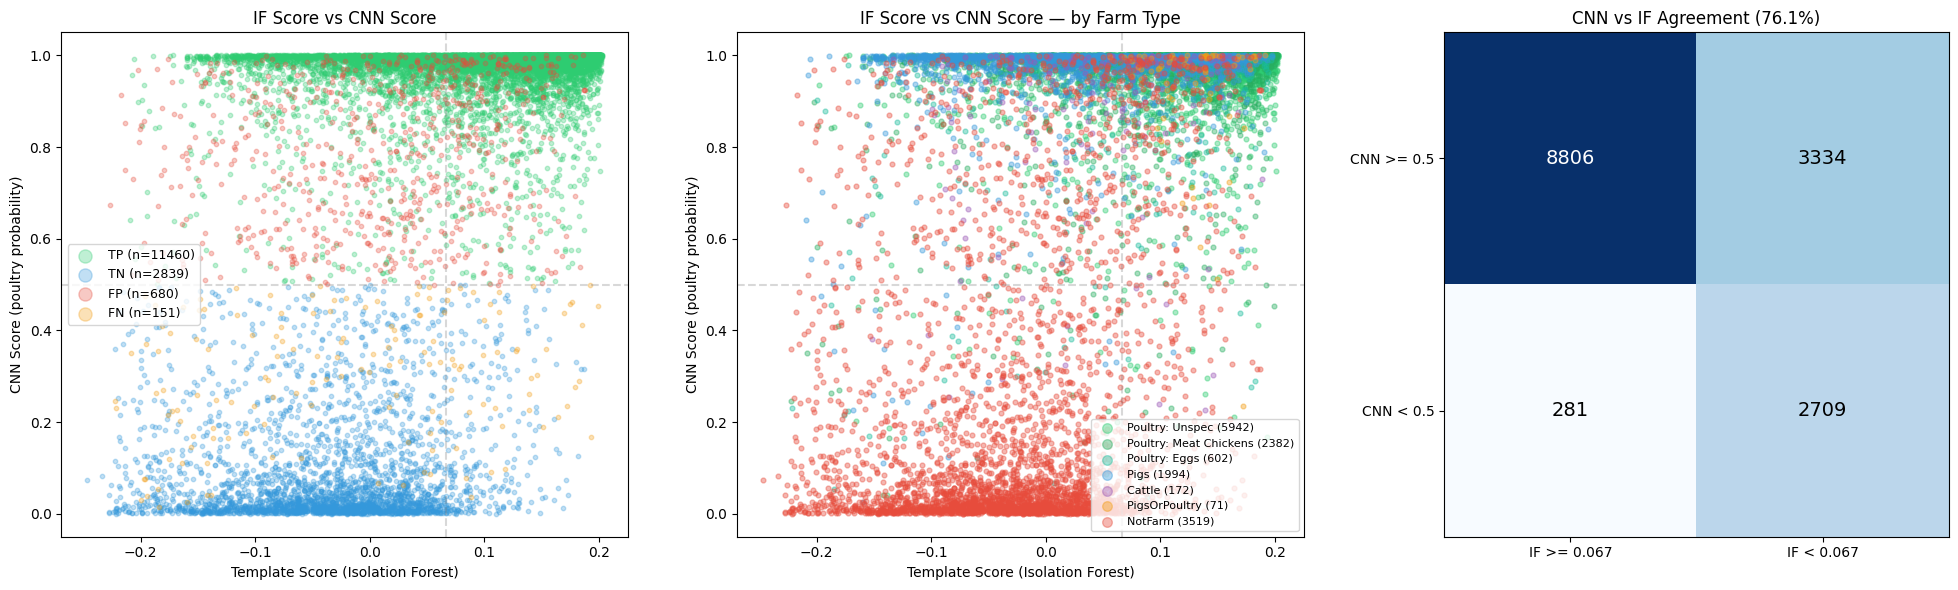

Pearson correlation (IF vs CNN): 0.581


In [11]:
has_both = scored[scored["template_score_if"].notna()].copy()
print(f"Candidates with both IF and CNN scores: {len(has_both)}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Scatter by pred_class
for cls in ["TP", "TN", "FP", "FN"]:
    sub = has_both[has_both["pred_class"] == cls]
    axes[0].scatter(sub["template_score_if"], sub["predicted_score"],
                    alpha=0.3, s=10, label=f"{cls} (n={len(sub)})", color=COLORS[cls])
axes[0].set_xlabel("Template Score (Isolation Forest)")
axes[0].set_ylabel("CNN Score (positive class probability)")
axes[0].set_title("IF Score vs CNN Score")
axes[0].axhline(CNN_THRESHOLD, color="gray", linestyle="--", alpha=0.3)
axes[0].axvline(IF_THRESHOLD, color="gray", linestyle="--", alpha=0.3)
axes[0].legend(markerscale=3, fontsize=9)

# Scatter by farm type
type_colors = {
    "Farm: Poultry: Unspecified/Other": "#2ecc71",
    "Farm: Poultry: Meat Chickens": "#27ae60",
    "Farm: Poultry: Eggs": "#1abc9c",
    "Farm: Pigs": "#3498db",
    "Farm: Cattle": "#9b59b6",
    "Farm: PigsOrPoultry": "#f39c12",
    "NotFarm": "#e74c3c",
}
for ft, color in type_colors.items():
    sub = has_both[has_both["farm_type"] == ft]
    if len(sub) == 0: continue
    short = ft.replace("Farm: ", "").replace("Unspecified/Other", "Unspec")
    axes[1].scatter(sub["template_score_if"], sub["predicted_score"],
                    alpha=0.4, s=12, label=f"{short} ({len(sub)})", color=color)
axes[1].set_xlabel("Template Score (Isolation Forest)")
axes[1].set_ylabel("CNN Score (positive class probability)")
axes[1].set_title("IF Score vs CNN Score — by Farm Type")
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.3)
axes[1].axvline(0.067, color="gray", linestyle="--", alpha=0.3)
axes[1].legend(markerscale=2, fontsize=8, loc="lower right")

# Agreement matrix
has_both["if_positive"] = has_both["template_score_if"] >= IF_THRESHOLD
has_both["cnn_positive"] = has_both["predicted_score"] >= CNN_THRESHOLD
agreement = (has_both["if_positive"] == has_both["cnn_positive"]).mean()

both_pos = ((has_both["if_positive"]) & (has_both["cnn_positive"])).sum()
if_only = ((has_both["if_positive"]) & (~has_both["cnn_positive"])).sum()
cnn_only = ((~has_both["if_positive"]) & (has_both["cnn_positive"])).sum()
both_neg = ((~has_both["if_positive"]) & (~has_both["cnn_positive"])).sum()

conf = np.array([[both_pos, cnn_only], [if_only, both_neg]])
im = axes[2].imshow(conf, cmap="Blues")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels([f"IF >= {IF_THRESHOLD}", f"IF < {IF_THRESHOLD}"])
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels([f"CNN >= {CNN_THRESHOLD}", f"CNN < {CNN_THRESHOLD}"])
axes[2].set_title(f"CNN vs IF Agreement ({agreement:.1%})")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(conf[i, j]), ha="center", va="center", fontsize=14,
                     color="white" if conf[i, j] > conf.max() / 2 else "black")

plt.tight_layout()
plt.show()

# Correlation
corr = has_both[["template_score_if", "predicted_score"]].corr().iloc[0, 1]
print(f"Pearson correlation (IF vs CNN): {corr:.3f}")

## 7. Per-Country Metrics

In [12]:
country_rows = []
for country in sorted(scored["country"].dropna().unique()):
    grp = scored[scored["country"] == country]
    tp = (grp["pred_class"] == "TP").sum()
    fp = (grp["pred_class"] == "FP").sum()
    fn = (grp["pred_class"] == "FN").sum()
    tn = (grp["pred_class"] == "TN").sum()
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-8)
    country_rows.append({"Country": country, "N": len(grp), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                         "Precision": f"{prec:.3f}", "Recall": f"{rec:.3f}", "F1": f"{f1:.3f}"})

display(pd.DataFrame(country_rows))

,Country,N,TP,FP,FN,TN,Precision,Recall,F1
0,Brazil,705,460,122,4,119,0.790,0.991,0.880
1,Chile,505,431,43,7,24,0.909,0.984,0.945
2,Mexico,2508,2174,128,45,161,0.944,0.980,0.962
3,Thailand,943,513,119,61,250,0.812,0.894,0.851
4,United States,10469,7882,268,34,2285,0.967,0.996,0.981


## 8. Inspected Set — Detailed Breakdown

In [13]:
insp = scored[scored["split"] == "inspected"]
if len(insp) == 0:
    print("No inspected split found")
else:
    print(f"Inspected set: {len(insp)} candidates")
    print()
    
    # Per-country
    print(f"{'Country':20s}  {'N':>4s}  {'TP':>4s} {'(med)':>6s}  {'FP':>4s} {'(med)':>6s}  {'FN':>4s} {'(med)':>6s}  {'TN':>4s} {'(med)':>6s}")
    print("-" * 80)
    for country in sorted(insp["country"].dropna().unique()):
        sub = insp[insp["country"] == country]
        parts = [f"{country:20s}  {len(sub):4d}"]
        for cls in ("TP", "FP", "FN", "TN"):
            csub = sub[sub["pred_class"] == cls]
            n = len(csub)
            if n > 0:
                parts.append(f"  {n:4d} {csub['predicted_score'].median():6.3f}")
            else:
                parts.append(f"  {n:4d}      -")
        print("".join(parts))
    
    print()
    # Per farm type in inspected
    print(f"{'Farm Type':40s} {'N':>5s} {'TP':>5s} {'FP':>5s} {'FN':>5s} {'TN':>5s} {'med':>6s}")
    print("-" * 75)
    for ft in insp["farm_type"].value_counts().index:
        if pd.isna(ft): continue
        sub = insp[insp["farm_type"] == ft]
        tp = (sub["pred_class"] == "TP").sum()
        fp = (sub["pred_class"] == "FP").sum()
        fn = (sub["pred_class"] == "FN").sum()
        tn = (sub["pred_class"] == "TN").sum()
        print(f"{ft:40s} {len(sub):5d} {tp:5d} {fp:5d} {fn:5d} {tn:5d} {sub['predicted_score'].median():6.3f}")

Inspected set: 1105 candidates

Country                  N    TP  (med)    FP  (med)    FN  (med)    TN  (med)
--------------------------------------------------------------------------------
Brazil                 305   218  0.988    60  0.903     2  0.475    25  0.256
Chile                  170   132  0.995    29  0.911     3  0.376     6  0.288
Mexico                 241   185  0.988    40  0.939     3  0.240    13  0.170
Thailand               128    94  0.969    22  0.826     3  0.354     9  0.097
United States          261   159  0.995    34  0.862     3  0.235    65  0.100

Farm Type                                    N    TP    FP    FN    TN    med
---------------------------------------------------------------------------
Farm: Poultry: Unspecified/Other           329   324     0     5     0  0.992
NotFarm                                    303     0   185     0   118  0.671
Farm: Pigs                                 281   279     0     2     0  0.992
Farm: Cattle            

## 9. Sample Patches

In [14]:
RGB_CH = [2, 1, 0]  # B4, B3, B2

# Join patch_path from patch_meta
meta = pd.read_csv(PATCHES_DIR / "patch_meta.csv", usecols=["candidate_id", "patch_path"])
patch_path_map = dict(zip(meta["candidate_id"].astype(str), meta["patch_path"]))
scored["patch_path"] = scored["candidate_id"].astype(str).map(patch_path_map)
print(f"Matched patch_path: {scored['patch_path'].notna().sum()} / {len(scored)}")

def load_patch(row):
    pp = row.get("patch_path", "")
    if not pp or pd.isna(pp): return None
    p = PATCHES_DIR / pp
    return np.load(p) if p.exists() else None

def show_patches(subset, title, n=8):
    with_path = subset[subset["patch_path"].notna()]
    if len(with_path) == 0:
        print(f"{title}: no patches available")
        return
    samples = with_path.sample(min(n, len(with_path)), random_state=42)
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    if n == 1: axes = [axes]
    for i, (_, row) in enumerate(samples.iterrows()):
        if i >= n: break
        patch = load_patch(row)
        if patch is None:
            axes[i].text(0.5, 0.5, "No patch", ha="center")
            axes[i].axis("off"); continue
        rgb = np.stack([patch[ch] for ch in RGB_CH], axis=-1)
        p2, p98 = np.percentile(rgb, [2, 98])
        rgb = np.clip((rgb - p2) / max(p98 - p2, 1), 0, 1)
        axes[i].imshow(rgb)
        ft = str(row.get("farm_type", ""))[:18]
        score = row.get("predicted_score", 0)
        axes[i].set_title(f"{score:.2f}\n{ft}", fontsize=8)
        axes[i].axis("off")
    for j in range(i + 1, n): axes[j].axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_patches(scored[scored["pred_class"] == "TP"], "TP — Correctly detected postry farms")
show_patches(scored[scored["pred_class"] == "FP"], "FP — Predicted positive, actually not")
show_patches(scored[scored["pred_class"] == "FN"], "FN — Missed positives")
show_patches(scored[scored["pred_class"] == "TN"], "TN — Correctly rejected (pigs/cattle/notfarm)")

Matched patch_path: 0 / 15130
TP — Correctly detected poultry farms: no patches available
FP — Predicted poultry, actually not: no patches available
FN — Missed poultry farms: no patches available
TN — Correctly rejected (pigs/cattle/notfarm): no patches available


## 10. FP / FN Google Maps Links

In [15]:
def make_gmaps_table(subset, title, n=20, ascending=False):
    top = subset.sort_values("predicted_score", ascending=ascending).head(n)
    rows_html = ""
    for _, row in top.iterrows():
        lat, lng = row.get("lat", 0), row.get("lng", 0)
        score = row.get("predicted_score", 0)
        cid = str(row.get("candidate_id", ""))[:25]
        ft = str(row.get("farm_type", ""))[:30]
        country = str(row.get("country", ""))
        gmaps = f"https://www.google.com/maps/@{lat},{lng},500m/data=!3m1!1e3"
        rows_html += (
            f"<tr><td>{cid}</td><td>{score:.3f}</td><td>{ft}</td>"
            f"<td>{country}</td><td>{lat:.4f}, {lng:.4f}</td>"
            f'<td><a href="{gmaps}" target="_blank">Map</a></td></tr>'
        )
    display(HTML(
        f"<h4>{title} (top {n})</h4>"
        "<table border='1' style='border-collapse:collapse; font-size:12px;'>"
        "<tr><th>ID</th><th>Score</th><th>Type</th><th>Country</th><th>Lat,Lng</th><th>Verify</th></tr>"
        f"{rows_html}</table>"
    ))

fps = scored[scored["pred_class"] == "FP"]
fns = scored[scored["pred_class"] == "FN"]
make_gmaps_table(fps, "FP — Highest confidence false positives (predicted positive, actually not)")
make_gmaps_table(fns, "FN — Most confident misses (positives the model missed)", ascending=True)

ID,Score,Type,Country,"Lat,Lng",Verify
USA_cluster_4609,1.000,NotFarm,United States,"39.5523, -119.4550",Map
USA_cluster_15854,1.000,NotFarm,United States,"41.2111, -96.9604",Map
BRA_cluster_54082,1.000,NotFarm,Brazil,"-1.2278, -47.6668",Map
USA_cluster_32670,1.000,NotFarm,United States,"33.8140, -93.3592",Map
CHL_cluster_1167,1.000,NotFarm,Chile,"-33.4539, -71.3930",Map
USA_cluster_48766,0.999,NotFarm,United States,"37.5666, -87.7288",Map
USA_cluster_73722,0.999,NotFarm,United States,"32.1575, -82.5695",Map
USA_cluster_98202,0.999,NotFarm,United States,"44.0518, -75.7353",Map
CHL_cluster_2382,0.998,NotFarm,Chile,"-32.6515, -71.2033",Map
MEX_cluster_16838,0.998,NotFarm,Mexico,"19.6109, -100.3530",Map


ID,Score,Type,Country,"Lat,Lng",Verify
THA_cluster_7796,0.014,Farm: Unknown,Thailand,"13.6405, 101.0987",Map
THA_cluster_16615,0.026,Farm: Pigs,Thailand,"14.7977, 100.4378",Map
THA_cluster_7819,0.030,Farm: Unknown,Thailand,"13.6468, 101.0821",Map
BRA_cluster_7232,0.036,Farm: Poultry: Eggs,Brazil,"-29.5122, -51.1008",Map
THA_cluster_7811,0.038,Farm: Unknown,Thailand,"13.6438, 101.0978",Map
USA_cluster_57630,0.041,Farm: Poultry: Unspecified/Oth,United States,"42.9263, -86.1546",Map
USA_cluster_103206,0.042,Farm: Poultry: Unspecified/Oth,United States,"38.5834, -75.3256",Map
THA_cluster_16683,0.053,Farm: Poultry: Eggs,Thailand,"14.4835, 100.3662",Map
USA_cluster_100002,0.064,Farm: Unknown,United States,"42.0932, -73.9482",Map
MEX_cluster_16236,0.068,Farm: Poultry: Eggs,Mexico,"25.3059, -100.0060",Map
